# Project - Featurization Model selection and Tuning

## Predict House Prices

<b>Dataset Info : </b>

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.

19 house features plus the price and the id columns, along with 21613 observations.

<b>Column Info : </b>

id - a notation for a house<br>
date -Date house was sold <br>
price- Price is prediction target <br> 
bedrooms- Number of Bedrooms/House <br>
bathrooms- Number of bathrooms/bedrooms <br>
sqft_living- square footage of the home <br>
sqft_lot- square footage of the lot <br>
floors-Total floors (levels) in house <br>
waterfront- House which has a view to a waterfront <br>
view-Has been viewed <br>
condition-How good the condition is ( Overall ) <br>
grade-overall grade given to the housing unit, based on King County grading system <br>
sqft_above-square footage of house apart from basement <br>
sqft_basement-square footage of the basement <br>
yr_built-Built Year <br>
yr_renovated-Year when house was renovated <br>
zipcode-zip <br>
lat-Latitude coordinate <br>
long-Longitude coordinate <br>
sqft_living15-Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area-sqft_lot15  <br>
lotSize area in 2015(implies-- some renovations)  <br>
 

Steps –

1. Import libraries and read the dataset.
2. Explore Data Analysis. Find out how one variable related to other and distributions of data.
3. State your insights.
4. Build a linear regression model to predict the house prices
5. Try to find out important features or create new features to improve the performance for your model.
6. Use appropriate cross validations techniques to find out the best predictor parameters and best prediction.

<b>PS - You can change the order of steps or add additional steps to figure out the best solution.</b>

In [469]:
# Import all required library 

import numpy as np
import pandas as pd
import math

from sklearn.linear_model import LinearRegression
from sklearn import decomposition
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, cross_val_score,KFold,GridSearchCV,RandomizedSearchCV

# calculate accuracy measures and MSE, R Square Value
from sklearn import metrics
from sklearn.metrics import accuracy_score, mean_squared_error,r2_score

# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 



In [220]:
import warnings 
warnings.filterwarnings('ignore')

In [311]:
#Read data fro csv file
houseData_df = pd.read_csv("kc_house_data.csv")

In [312]:
houseData_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [313]:
houseData_df.shape

(21613, 21)

In [314]:
#There are 21613 Rows and 21 Column in our dataframe

In [315]:
houseData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [316]:
#Date column shows as object type,which needs to be convert as DateTime type

In [317]:
#Check summary statistics
houseData_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [318]:
#checking for Null values

def check_null(data):
    null_col_list=[]
    for col in data:
        if data[col].isnull().sum() >0:
            null_col_list.append(col)
        else:
            pass
    return null_col_list

In [319]:
null_col_list=check_null(houseData_df)
print("Columns with Null Values = {0}".format(null_col_list))

Columns with Null Values = []


#### Loooks there is no NULL value in our data set that really good.

In [320]:
#Convert "date" colune object type to "date" type
houseData_df["date"]=pd.to_datetime(houseData_df["date"])

houseData_df["houseSold_Year"]=houseData_df["date"].dt.year  # Create House Sold Year column
houseData_df["houseSold_Month"]=houseData_df["date"].dt.month # Create House Sold Month column

In [321]:
houseData_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,houseSold_Year,houseSold_Month
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [322]:
houseData_df.dtypes #Get Column types

id                          int64
date               datetime64[ns]
price                     float64
bedrooms                    int64
bathrooms                 float64
sqft_living                 int64
sqft_lot                    int64
floors                    float64
waterfront                  int64
view                        int64
condition                   int64
grade                       int64
sqft_above                  int64
sqft_basement               int64
yr_built                    int64
yr_renovated                int64
zipcode                     int64
lat                       float64
long                      float64
sqft_living15               int64
sqft_lot15                  int64
houseSold_Year              int64
houseSold_Month             int64
dtype: object

In [323]:
#print unique values of number of unique values for our features
print('Dates \n', houseData_df['date'].nunique())
print('Years \n', houseData_df['houseSold_Year'].unique())
print('Months \n', houseData_df['houseSold_Month'].unique())
print('Bedrooms \n', houseData_df['bedrooms'].unique())
print('Bathrooms \n', houseData_df['bathrooms'].unique())
print('Floors \n', houseData_df['floors'].unique())
print('Waterfront \n', houseData_df['waterfront'].unique())
print('Views \n', houseData_df['view'].unique())
print('Condition \n', houseData_df['condition'].unique())
print('Grades \n', houseData_df['grade'].unique())
print('Years Built \n', houseData_df['yr_built'].unique())
print('Years Renovated \n', houseData_df['yr_renovated'].unique())
print('Zip Codes \n', houseData_df['zipcode'].unique())
print('Latitude \n', houseData_df['lat'].nunique())
print('Longitude \n', houseData_df['long'].nunique())
print('Square Foot Living \n', houseData_df['sqft_living'].nunique())
print('Square Foot Lot \n', houseData_df['sqft_lot'].nunique())
print('Square Foot Living 15\n', houseData_df['sqft_living15'].nunique())
print('Square Foot Lot 15\n', houseData_df['sqft_lot15'].nunique())
print('Square Foot Above \n', houseData_df['sqft_above'].nunique())
print('Square Foot Basement \n', houseData_df['sqft_basement'].nunique())


print('Minimum-Years Built \n', houseData_df['yr_built'].min())
print('Minimum-Years Built \n', houseData_df['yr_built'].max())

Dates 
 372
Years 
 [2014 2015]
Months 
 [10 12  2  5  6  1  4  3  7  8 11  9]
Bedrooms 
 [ 3  2  4  5  1  6  7  0  8  9 11 10 33]
Bathrooms 
 [1.   2.25 3.   2.   4.5  1.5  2.5  1.75 2.75 3.25 4.   3.5  0.75 4.75
 5.   4.25 3.75 0.   1.25 5.25 6.   0.5  5.5  6.75 5.75 8.   7.5  7.75
 6.25 6.5 ]
Floors 
 [1.  2.  1.5 3.  2.5 3.5]
Waterfront 
 [0 1]
Views 
 [0 3 4 2 1]
Condition 
 [3 5 4 1 2]
Grades 
 [ 7  6  8 11  9  5 10 12  4  3 13  1]
Years Built 
 [1955 1951 1933 1965 1987 2001 1995 1963 1960 2003 1942 1927 1977 1900
 1979 1994 1916 1921 1969 1947 1968 1985 1941 1915 1909 1948 2005 1929
 1981 1930 1904 1996 2000 1984 2014 1922 1959 1966 1953 1950 2008 1991
 1954 1973 1925 1989 1972 1986 1956 2002 1992 1964 1952 1961 2006 1988
 1962 1939 1946 1967 1975 1980 1910 1983 1978 1905 1971 2010 1945 1924
 1990 1914 1926 2004 1923 2007 1976 1949 1999 1901 1993 1920 1997 1943
 1957 1940 1918 1928 1974 1911 1936 1937 1982 1908 1931 1998 1913 2013
 1907 1958 2012 1912 2011 1917 1932 1944 1902 2

### Data Obervation : 

1. We have around 372 days data in span of year 2014 to 2015.
2. We can see that that we have houses built from 1900 to 2015.
3. Waterfront is binnary which should be decoded.
4. View, condition and grade features look like ordinal categorical type, this also to be decoded.
5. Max. bedrooms is 33. We need to verify this value, it may be typo.

In [195]:
# Verify data where bedrooms is > 10
print(houseData_df.loc[houseData_df['bedrooms'] >10,:] )

               id       date     price  bedrooms  bathrooms  sqft_living  \
8757   1773100755 2014-08-21  520000.0        11       3.00         3000   
15870  2402100895 2014-06-25  640000.0        33       1.75         1620   

       sqft_lot  floors  waterfront  view       ...         sqft_basement  \
8757       4960     2.0           0     0       ...                   600   
15870      6000     1.0           0     0       ...                   580   

       yr_built  yr_renovated  zipcode      lat     long  sqft_living15  \
8757       1918          1999    98106  47.5560 -122.363           1420   
15870      1947             0    98103  47.6878 -122.331           1330   

       sqft_lot15  houseSold_Year  houseSold_Month  
8757         4960            2014                8  
15870        4700            2014                6  

[2 rows x 23 columns]


In [196]:
# looks like bedrooms 33 and bathroom is 1.75,which is clearly say that its typo.
#since it has only one row we can drop this one row 

In [324]:
#Drop 33 bedroom row in our dataset
toDrop = houseData_df.loc[houseData_df['bedrooms'] == 33,'bedrooms'].index.tolist()
houseData_df.drop(toDrop, axis = 0, inplace = True)

print('Bedrooms \n', houseData_df['bedrooms'].unique())

Bedrooms 
 [ 3  2  4  5  1  6  7  0  8  9 11 10]


In [325]:
#create new features
houseData_df.loc[houseData_df.loc[:,'yr_renovated'] > 0 , "renovated"] = 1
houseData_df.loc[houseData_df.loc[:,'yr_renovated'] == 0, "renovated"] = 0

houseData_df.loc[houseData_df.loc[:,'sqft_basement'] > 0 , "hasBsmnt"] = 1
houseData_df.loc[houseData_df.loc[:,'sqft_basement'] == 0, "hasBsmnt"] = 0

In [202]:
houseData_df.renovated.value_counts()

0.0    20698
1.0      914
Name: renovated, dtype: int64

In [203]:
houseData_df.hasBsmnt.value_counts()

0.0    13126
1.0     8486
Name: hasBsmnt, dtype: int64

In [298]:
#Decode zipcode
houseData_df['zipTop'] = 'otherZip'
houseData_df.loc[houseData_df['zipcode'] == 98039, 'zipTop'] = 'zip1'
houseData_df.loc[houseData_df['zipcode'] == 98004, 'zipTop'] = 'zip2'
houseData_df.loc[houseData_df['zipcode'] == 98040, 'zipTop'] = 'zip3'
houseData_df.loc[houseData_df['zipcode'] == 98112, 'zipTop'] = 'zip4'

#encode zipTop
dummies = pd.get_dummies(houseData_df.loc[:, 'zipTop'], drop_first = True)
houseData_df[list(dummies.columns)] = dummies

### Find Distribution of each variables

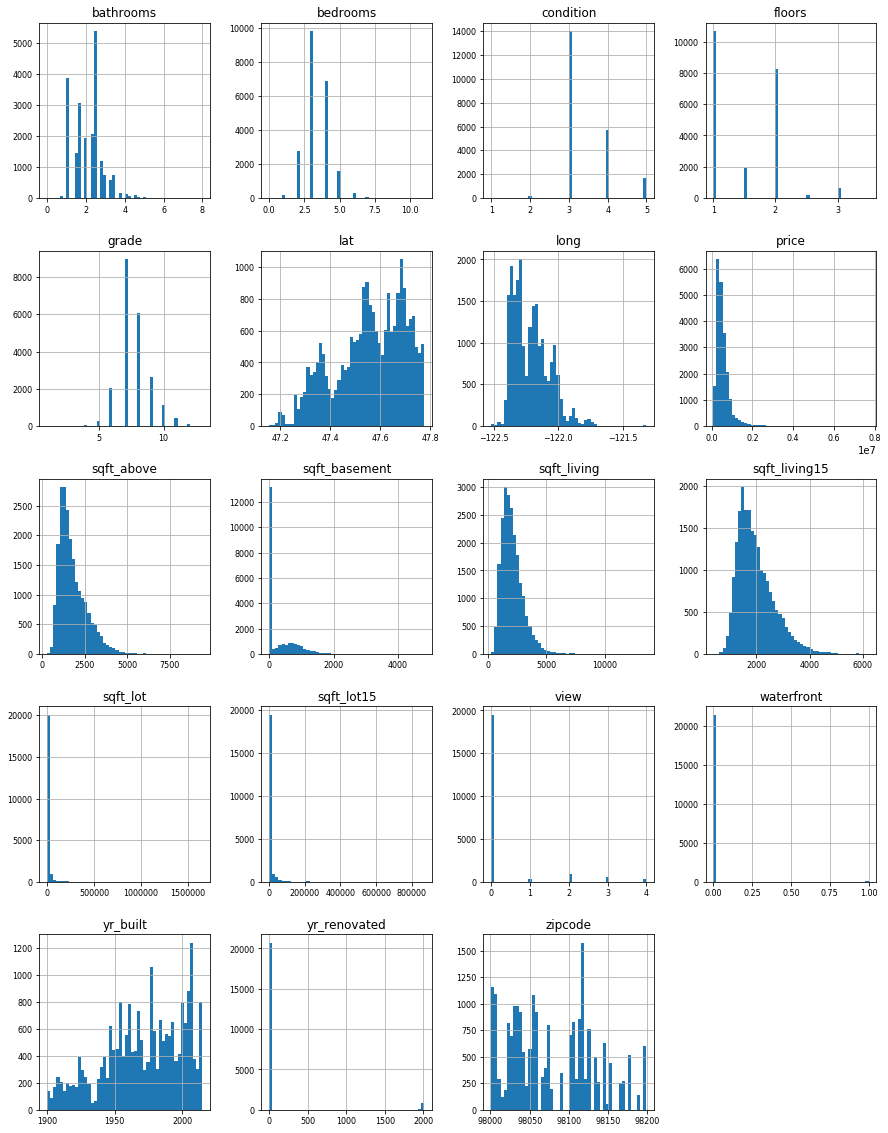

In [43]:
# Plot the distribution for each variable
houseData_df[["price","bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","condition","grade","sqft_above","sqft_basement","yr_built","yr_renovated","zipcode","lat","long","sqft_living15","sqft_lot15"]].hist(figsize=(15,20),bins = 50,xlabelsize=8,ylabelsize =8)
plt.show()

## Uni-Variate And Bi-Variate Analysis

### 1. Bedroom Vs Price Analysis

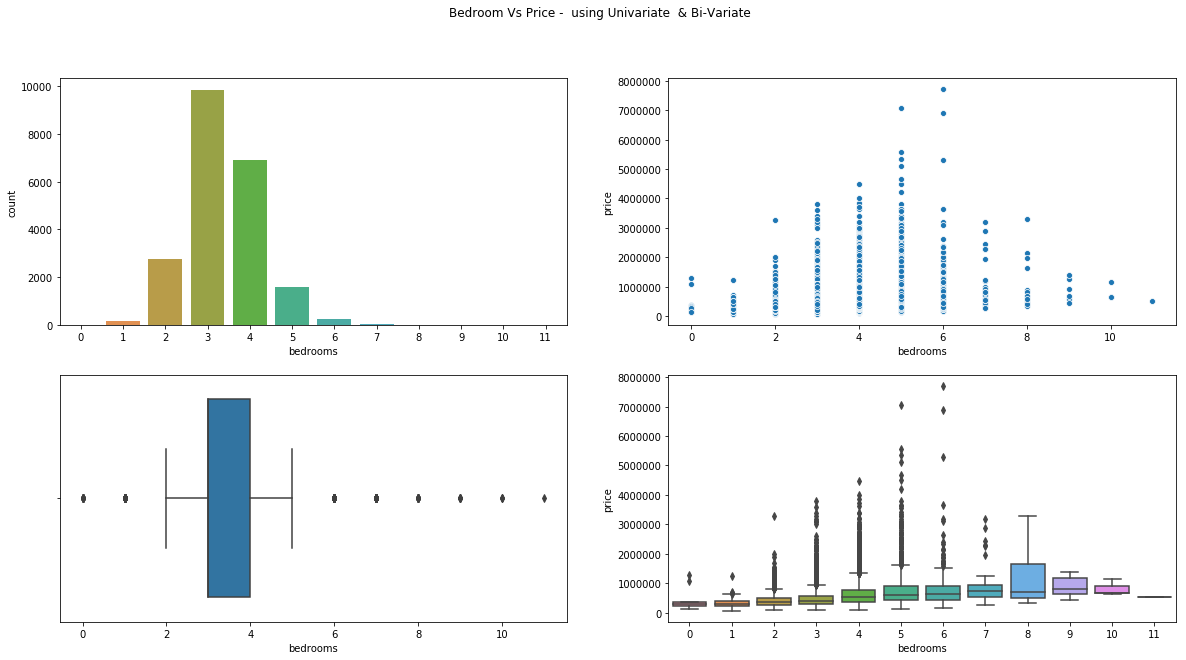

In [44]:
#Bedroom Vs Price using Univariate  & Bi-Variate
a4_dims = (20, 10)
fig, ax = plt.subplots(nrows=2, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('Bedroom Vs Price -  using Univariate  & Bi-Variate')

sns.countplot(x="bedrooms", data=houseData_df,ax=ax[0][0])
sns.scatterplot(data=houseData_df, y="price",x="bedrooms",ax=ax[0][1]);
sns.boxplot(data=houseData_df, x="bedrooms",ax=ax[1][0]);
sns.boxplot(data=houseData_df, y="price",x="bedrooms",ax=ax[1][1]);

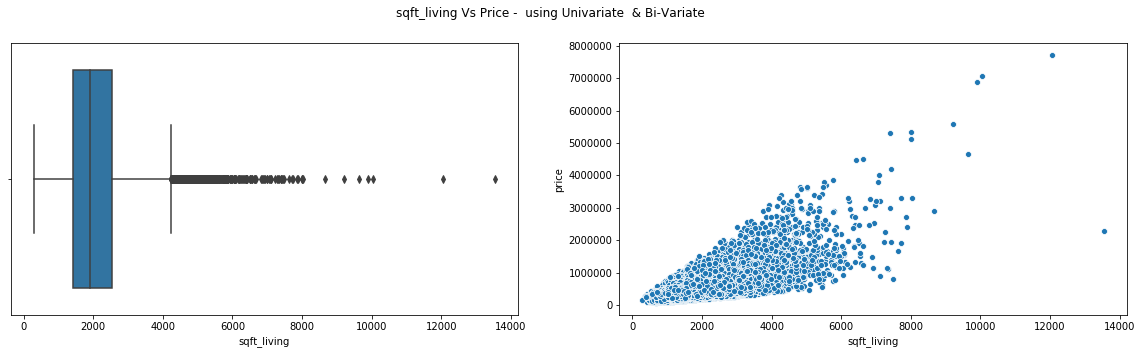

In [22]:
#sqft_living Vs Price using Univariate  & Bi-Variate
a4_dims = (20, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('sqft_living Vs Price -  using Univariate  & Bi-Variate')

sns.boxplot(data=houseData_df, x="sqft_living",ax=ax[0]);
sns.scatterplot(data=houseData_df, y="price",x="sqft_living",ax=ax[1]);



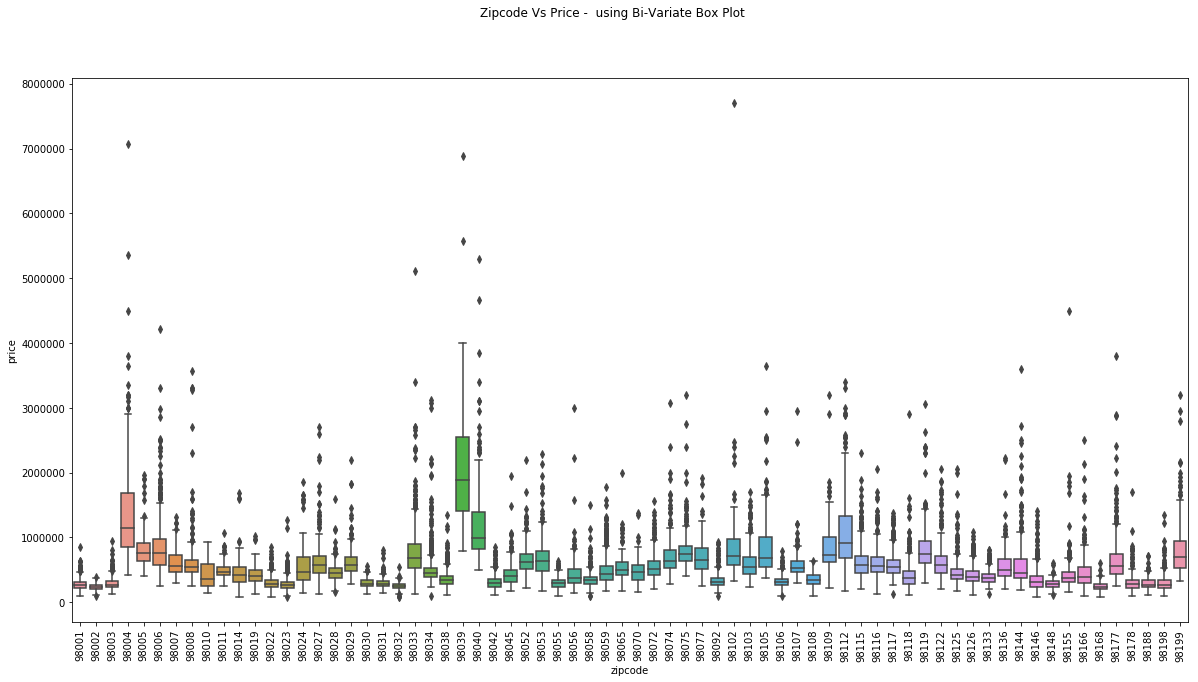

In [53]:
#Bedroom Vs Price using Bi-Variate Box Plot
a4_dims = (20, 10)
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('Zipcode Vs Price -  using Bi-Variate Box Plot')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
sns.boxplot(data=houseData_df, y="price",x="zipcode");


### Water front Vs Price Analysis

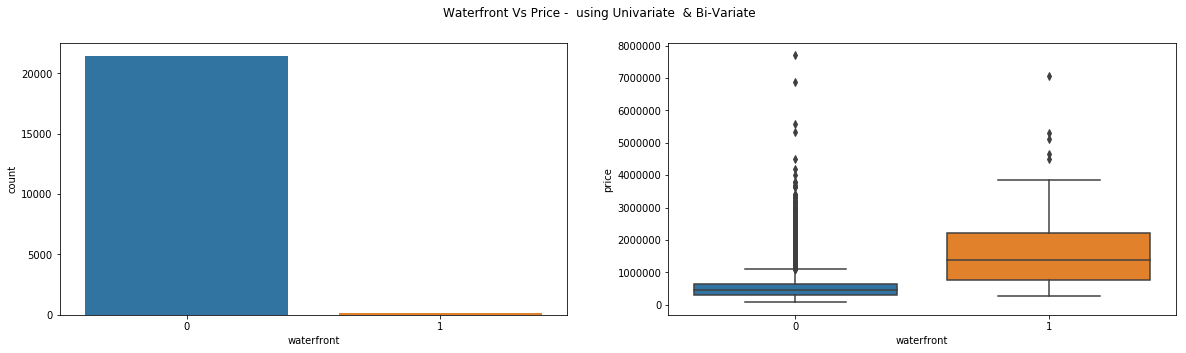

In [49]:
#Bedroom Vs Price using Univariate  & Bi-Variate
a4_dims = (20, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('Waterfront Vs Price -  using Univariate  & Bi-Variate')

sns.countplot(x="waterfront", data=houseData_df,ax=ax[0])
sns.boxplot(data=houseData_df, y="price",x="waterfront",ax=ax[1]);


## Grade Vs Price Analysis

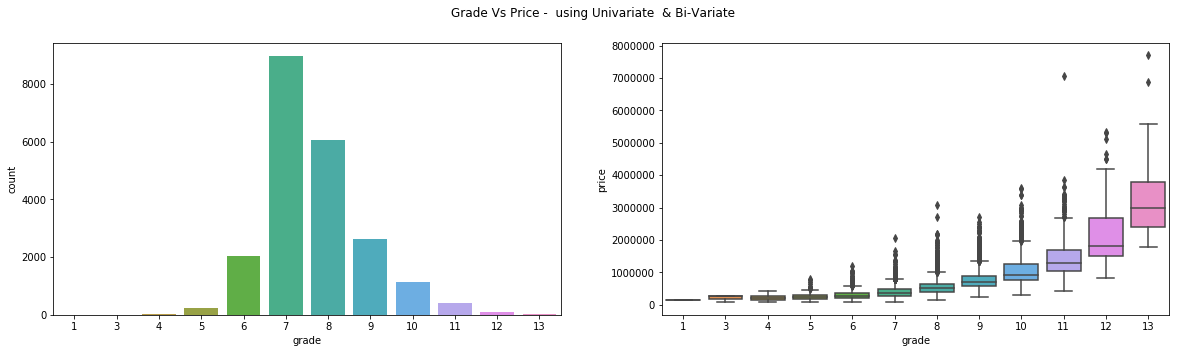

In [51]:
#Grade Vs Price using Univariate  & Bi-Variate
a4_dims = (20, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('Grade Vs Price -  using Univariate  & Bi-Variate')

sns.countplot(x="grade", data=houseData_df,ax=ax[0])
sns.boxplot(data=houseData_df, y="price",x="grade",ax=ax[1]);

### Condition Vs Price Analysis

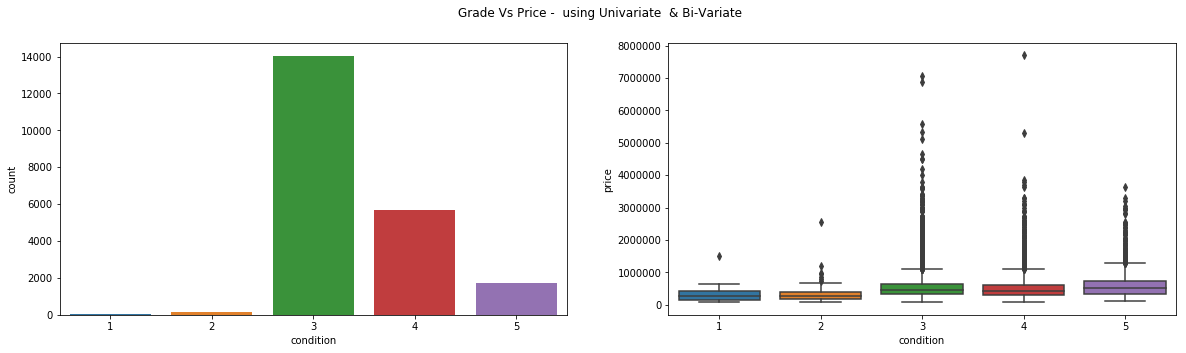

In [52]:
#Condition Vs Price using Univariate  & Bi-Variate
a4_dims = (20, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('Condition Vs Price -  using Univariate  & Bi-Variate')

sns.countplot(x="condition", data=houseData_df,ax=ax[0])
sns.boxplot(data=houseData_df, y="price",x="condition",ax=ax[1]);

### View Vs Price Analysis

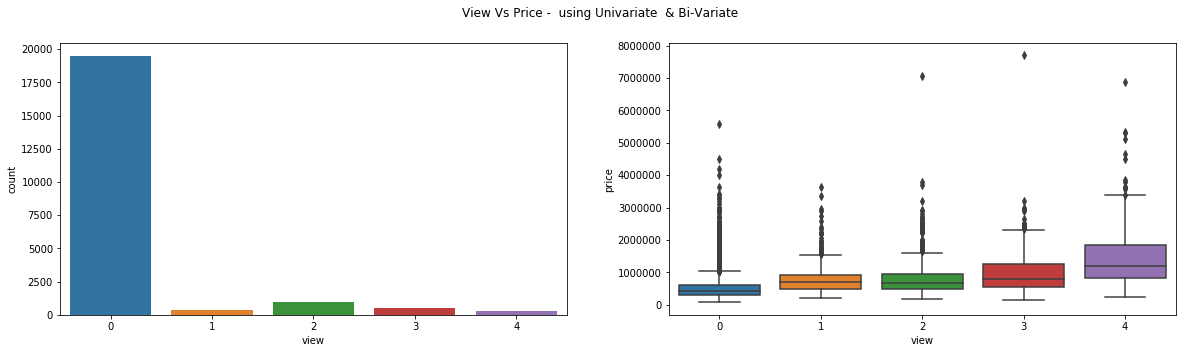

In [54]:
#View Vs Price using Univariate  & Bi-Variate
a4_dims = (20, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('View Vs Price -  using Univariate  & Bi-Variate')

sns.countplot(x="view", data=houseData_df,ax=ax[0])
sns.boxplot(data=houseData_df, y="price",x="view",ax=ax[1]);

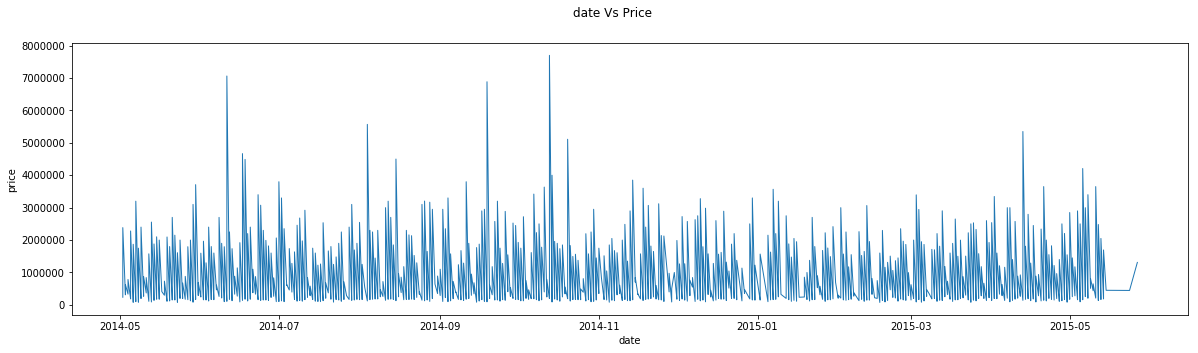

In [24]:
a4_dims = (20, 5)
fig, ax = plt.subplots(figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('date Vs Price')

sns.lineplot(x=houseData_df["date"], y=houseData_df["price"], sort=True, lw=1,estimator=None)

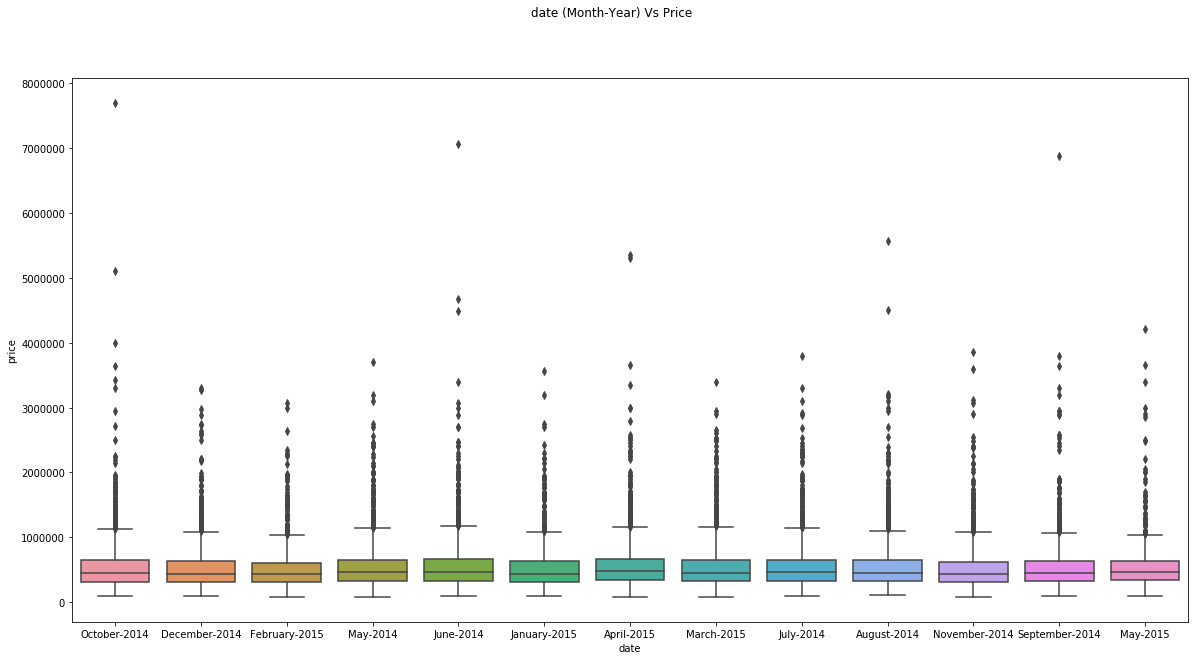

In [25]:
a4_dims = (20, 10)
fig, ax = plt.subplots(figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('date (Month-Year) Vs Price')

sns.boxplot(x=houseData_df["date"].apply(lambda x: x.strftime('%B-%Y')) , y=houseData_df["price"])



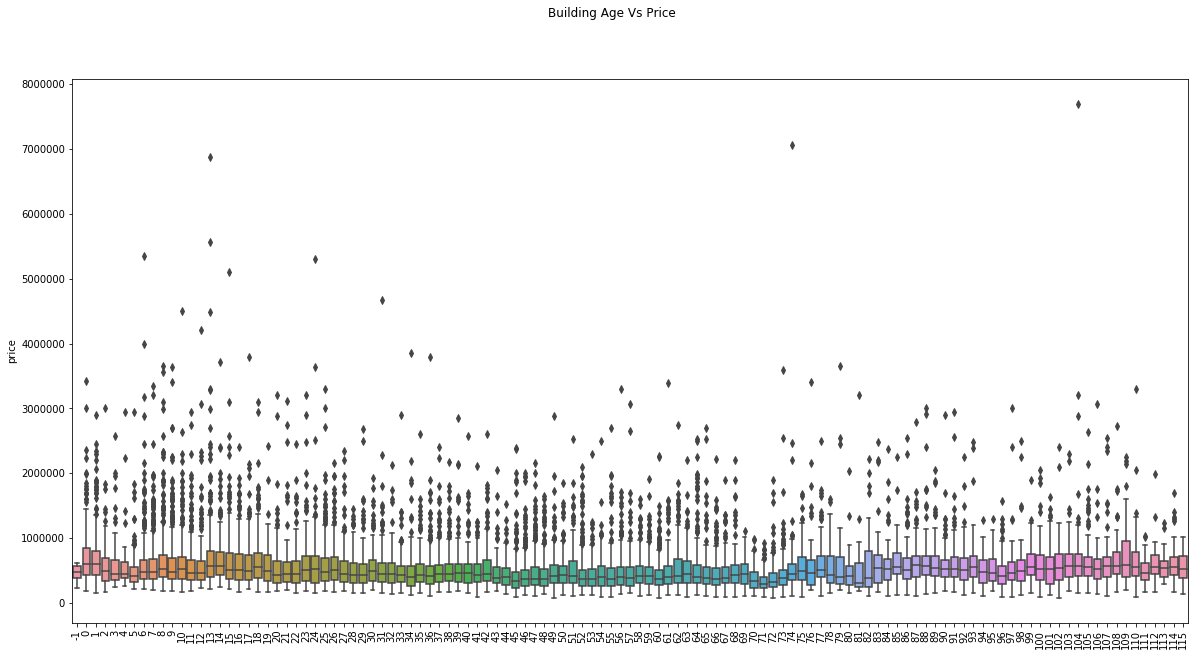

In [56]:
a4_dims = (20, 10)
fig, ax = plt.subplots(figsize=a4_dims)
fig.subplots_adjust(hspace=0.2)
fig.suptitle('Building Age Vs Price')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
sns.boxplot(x=(houseData_df["houseSold_Year"]-houseData_df["yr_built"]) , y=houseData_df["price"])

In [326]:
houseData_df["Building_Age"]=houseData_df["houseSold_Year"]-houseData_df["yr_built"]

In [327]:
houseData_df["Building_Age"].unique()

array([ 59,  63,  82,  49,  28,  13,  19,  52,  55,  12,  50,  72,  87,
        37, 115,  36,  20,  98,  93,  46,  67,  29,  73,  99, 105,  66,
        10,  11,   9,  85,  33,  84,  81, 110,  18,  14,  30,   0,  92,
        62,  64,  34,  88,   6,  24,  60,  41,  35,  89,  25,  43,  58,
        74,  22,  51,  53,   8,  26,  75,  68,  48,  39, 104,  31, 114,
         4,  69,  65,  90,  27, 101,  47,  54, 109,   7,  61,  15,  38,
        16, 113,  21,  94,  45, 100, 111,  96,  97,  86, 103,  78,  77,
        76, 107,  40,  57, 102,  17,  71,   1,  23,  91,  42,  95,   2,
        32,   3,  56,  70,  44, 112,   5,  80,  83, 106, 108,  79,  -1],
      dtype=int64)

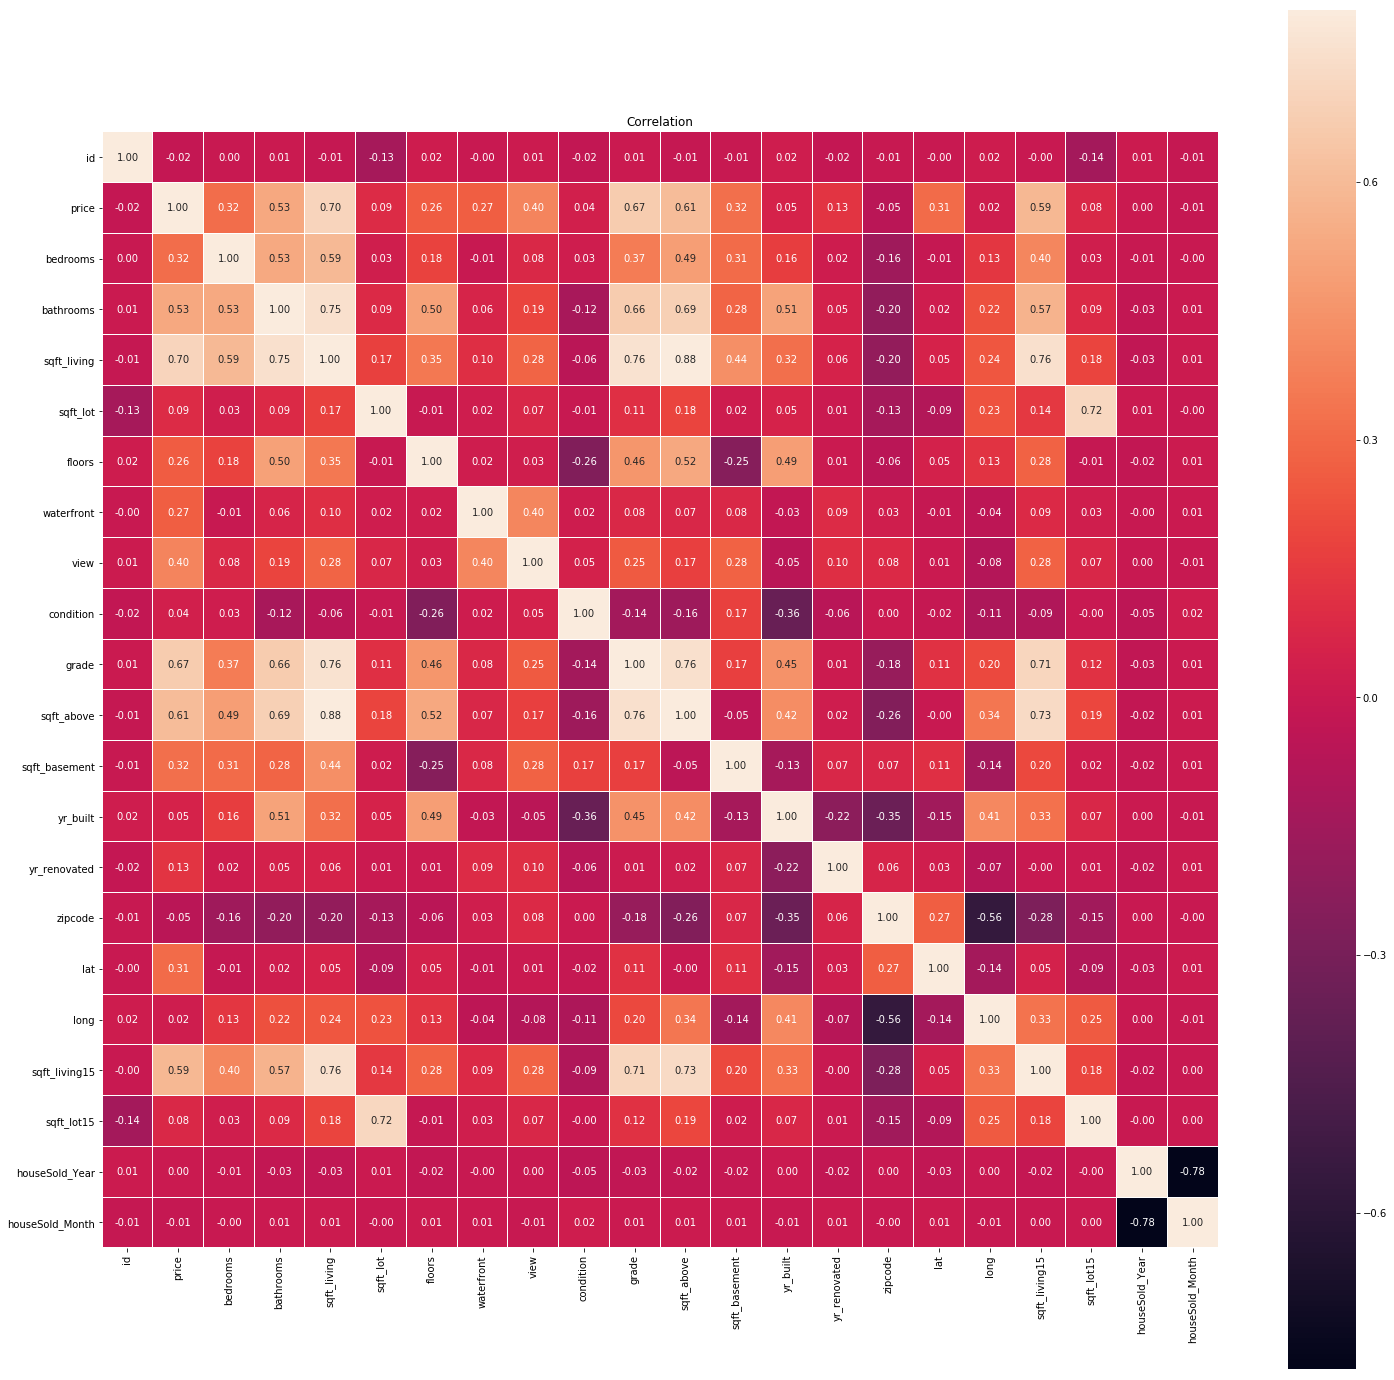

In [26]:
# Correlation with Heatmap. This help us to know each variable liner correlation with each other in a matrix form
plt.figure(figsize=(25, 25))
ax = sns.heatmap(houseData_df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

### Normalize price data

In [328]:
houseData_df['log_price'] = np.log(houseData_df['price'])

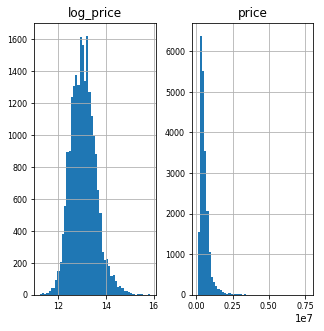

In [329]:
houseData_df[["price","log_price"]].hist(figsize=(5,5),bins = 50,xlabelsize=8,ylabelsize =8)
plt.show()

### Split the dataset into training and test set in the ratio of 70:30 (Training:Test)

In [412]:
# Get independent variable in X. Drop Status & name column from the dataset. 
#Since Status is Target variable & name column not required to buld the model

#Create new df
houseData_ready_df = houseData_df.copy(deep = True)

X = houseData_ready_df.drop(["id","price","date","houseSold_Year","yr_built","log_price",'yr_renovated','sqft_basement'], axis=1)
# Get Target variable in y
y = houseData_df["log_price"]

### Standardization of data

In [413]:
#Standardize the data

from sklearn.preprocessing import StandardScaler

#Since the dimensions of the data are not really known to us, 
#it would be wise to standardize the features using StandardScaler before we go for any modeling. 

X_std = StandardScaler().fit_transform(X)

X_std

array([[-0.40692359, -1.44745951, -0.97984121, ..., -0.21014009,
        -0.80405418,  0.53389789],
       [-0.40692359,  0.17558163,  0.53360192, ...,  4.75873032,
         1.24369728,  0.67006787],
       [-1.50829275, -1.44745951, -1.42625249, ..., -0.21014009,
        -0.80405418,  1.31687525],
       ...,
       [-1.50829275, -1.77206774, -1.15405049, ..., -0.21014009,
        -0.80405418, -1.30439679],
       [-0.40692359,  0.50018986, -0.52254184, ..., -0.21014009,
        -0.80405418, -1.10014182],
       [-1.50829275, -1.77206774, -1.15405049, ..., -0.21014009,
        -0.80405418, -1.27035429]])

In [414]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=test_size, random_state=seed)

In [415]:
print("House Dataframe - Train Data Shape : {0}".format(X_train.shape))
print("House Dataframe - Test Data Shape : {0}".format(X_test.shape))
print("House Dataframe Full Data Shape : {0}".format(X.shape))

House Dataframe - Train Data Shape : (15128, 19)
House Dataframe - Test Data Shape : (6484, 19)
House Dataframe Full Data Shape : (21612, 19)


In [416]:
model1 = LinearRegression()


In [417]:
model1.fit(X_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [418]:
model1_y_predict=  model1.predict(X_test)

In [419]:
model1.score(X_test,y_test)

0.768807267578513

In [420]:
scores=cross_val_score(model1,X_test,y_test,cv=5)

In [421]:
np.mean(scores)

0.7673434474991027

In [422]:
np.std(scores)

0.009981593849036074

In [423]:
print("%0.2f (+/- %0.2f)" % ((scores.mean()*100), scores.std() * 2))

76.73 (+/- 0.02)


In [424]:
def Calculate_LinearRegressionModel_Metrics(modealName,modealDetails,model,xTest,yTest):
    model_Result=pd.DataFrame(index=["ModelName","Details","Score","Root Mean Squared Error (RMSE) Value","R-Squared Value","5-Fold Cross Validation","Cross Validation Accuracy"])
    y_predict=model.predict(xTest)
    rmse = float(format(np.sqrt(mean_squared_error(y_predict,yTest)),'.3f'))
    rsqv = float(format(r2_score(y_predict,yTest),'.3f'))
    cv_score = cross_val_score(model,xTest,yTest,cv=5)
    cv = float(format(np.mean(cv_score),'.3f'))
    cv_Accuracy=("%0.2f (+/- %0.2f)" % ((np.mean(cv_score)*100), np.std(cv_score) * 2))
    modelscore = float(format(model.score(X_test,y_test),'.3f'))
    model_Result[modealName]=[modealName,modealDetails,modelscore,rmse,rsqv,cv,cv_Accuracy]
     
    return model_Result

In [425]:
model1_Result = Calculate_LinearRegressionModel_Metrics("Simple Linear Regression1"," ",model1,X_test,y_test)

In [426]:
model1_Result

,Simple Linear Regression
ModelName,Simple Linear Regression
Details,All Features & no normalize
Score,0.769
Root Mean Squared Error (RMSE) Value,0.251
R-Squared Value,0.704
5-Fold Cross Validation,0.767
Cross Validation Accuracy,76.73 (+/- 0.02)


### Model : Gradient Boosting Regressor - Ensemble

In [509]:
# Let's try modeling with GradientBoostingRegressor

from sklearn import ensemble

In [510]:
model2 = ensemble.GradientBoostingRegressor(n_estimators = 100)
model2.fit(X_train,y_train)

GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='ls', max_depth=3, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_samples_split=2, min_weight_fraction_leaf=0.0,
             n_estimators=100, n_iter_no_change=None, presort='auto',
             random_state=None, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False)

In [511]:
model2.score(X_test,y_test)

0.8812330587720758

In [512]:
model2_Result = Calculate_LinearRegressionModel_Metrics("Gradient Boosting Regression1","with n_estimators=100 and other default value",model2,X_test,y_test)

model2_Result

,Gradient Boosting Regression1
ModelName,Gradient Boosting Regression1
Details,with n_estimators=100 and other default value
Score,0.881
Root Mean Squared Error (RMSE) Value,0.18
R-Squared Value,0.86
5-Fold Cross Validation,0.876
Cross Validation Accuracy,87.62 (+/- 0.01)


In [445]:
#Hyper Parameters Set
params={'n_estimators':[100,200,300,400,500],
            'learning_rate': [0.1, 0.05, 0.02, 0.01],
            'max_depth':[3,4,5,6],
            'min_samples_leaf':[3],
            'loss' : ['ls']}
#Making models with hyper parameters sets
rscv_GBR = RandomizedSearchCV(model2, param_distributions=params)

In [446]:
rscv_GBR.fit(X_std,y)

RandomizedSearchCV(cv='warn', error_score='raise-deprecating',
          estimator=GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='ls', max_depth=3, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_sampl...=None, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False),
          fit_params=None, iid='warn', n_iter=10, n_jobs=None,
          param_distributions={'n_estimators': [100, 200, 300, 400, 500], 'learning_rate': [0.1, 0.05, 0.02, 0.01], 'max_depth': [3, 4, 5, 6], 'min_samples_leaf': [3], 'loss': ['ls']},
          pre_dispatch='2*n_jobs', random_state=None, refit=True,
          return_train_score='warn', scoring=None, verbose=0)

In [447]:
rscv_GBR.best_params_

{'n_estimators': 300,
 'min_samples_leaf': 3,
 'max_depth': 6,
 'loss': 'ls',
 'learning_rate': 0.05}

In [503]:
model3 = ensemble.GradientBoostingRegressor(n_estimators = 300, max_depth = 6, min_samples_split = 3,
          learning_rate = 0.05, loss = 'ls')

model3.fit(X_train,y_train)

GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.05, loss='ls', max_depth=6, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_samples_split=3, min_weight_fraction_leaf=0.0,
             n_estimators=300, n_iter_no_change=None, presort='auto',
             random_state=None, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False)

In [504]:
model3.score(X_test,y_test)

0.9059404057502836

In [507]:
model3_Result = Calculate_LinearRegressionModel_Metrics("Gradient Boosting Regression3","Best parameter from RandomizedSearchCV",model2,X_test,y_test)
model3_Result

,Gradient Boosting Regression3
ModelName,Gradient Boosting Regression3
Details,Best parameter from RandomizedSearchCV
Score,0.906
Root Mean Squared Error (RMSE) Value,0.16
R-Squared Value,0.896
5-Fold Cross Validation,0.893
Cross Validation Accuracy,89.27 (+/- 0.01)


### Model : Support Vector Machine (SVM) 

In [459]:
#Now let's try with SVM and let's see the performance of the model
from sklearn import svm

model4 = svm.SVR(kernel='linear')
model4.fit(X_train,y_train)

SVR(C=1.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.1,
  gamma='auto_deprecated', kernel='linear', max_iter=-1, shrinking=True,
  tol=0.001, verbose=False)

In [460]:
model4_Result = Calculate_LinearRegressionModel_Metrics("SVM1","Linear Kernel SVM",model4,X_test,y_test)
model4_Result

,SVM1
ModelName,SVM1
Details,Linear Kernel SVM
Score,0.768
Root Mean Squared Error (RMSE) Value,0.252
R-Squared Value,0.698
5-Fold Cross Validation,0.766
Cross Validation Accuracy,76.57 (+/- 0.02)


In [461]:
params = [    {        
     'kernel': ['linear',  'poly'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [465]:
rscv_SVM=RandomizedSearchCV(model4, param_distributions=params)

### Linear Regression with Principal Component Analysis

In [473]:
#Declare data preprocessing steps

LR=LinearRegression()
pca = decomposition.PCA()
pipe = Pipeline(steps=[('pca', pca), ('LinearRegression', LR)])

pca.fit(X) 

PCA(copy=True, iterated_power='auto', n_components=None, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [480]:
n_components = [4,6,8,10,12,14,16,18]
gs_PCA = GridSearchCV(pipe,dict(pca__n_components=n_components))
gs_PCA.fit(X_std,y)

GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=Pipeline(memory=None,
     steps=[('pca', PCA(copy=True, iterated_power='auto', n_components=None, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)), ('LinearRegression', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False))]),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'pca__n_components': [4, 6, 8, 10, 12, 14, 16, 18]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [481]:
gs_PCA.best_params_

{'pca__n_components': 18}

In [482]:
gs_PCA.best_score_

0.7707730761194487

In [497]:
pca = decomposition.PCA(n_components=14)
pca.fit(X_std) 

PCA(copy=True, iterated_power='auto', n_components=14, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [498]:
pipe = Pipeline(steps=[('pca', pca), ('LinearRegression', LR)])

In [499]:
pipe.fit(X_train,y_train)

Pipeline(memory=None,
     steps=[('pca', PCA(copy=True, iterated_power='auto', n_components=14, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)), ('LinearRegression', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False))])

In [500]:
model5_Result = Calculate_LinearRegressionModel_Metrics("PCA1","PCA with LR",pipe,X_test,y_test)
model5_Result

,PCA1
ModelName,PCA1
Details,PCA with LR
Score,0.762
Root Mean Squared Error (RMSE) Value,0.255
R-Squared Value,0.695
5-Fold Cross Validation,0.76
Cross Validation Accuracy,76.05 (+/- 0.02)


### Final Conclusion:

In [513]:
model_Result=pd.DataFrame(index=["ModelName","Details","Score","Root Mean Squared Error (RMSE) Value","R-Squared Value","5-Fold Cross Validation","Cross Validation Accuracy"])
model_Result["Model1"]=model1_Result
model_Result["Model2"]=model2_Result
model_Result["Model3"]=model3_Result
model_Result["Model4"]=model4_Result
model_Result["Model5"]=model5_Result

model_Result.T

,ModelName,Details,Score,Root Mean Squared Error (RMSE) Value,R-Squared Value,5-Fold Cross Validation,Cross Validation Accuracy
Model1,Simple Linear Regression,All Features & no normalize,0.769,0.251,0.704,0.767,76.73 (+/- 0.02)
Model2,Gradient Boosting Regression1,with n_estimators=100 and other default value,0.881,0.18,0.86,0.876,87.62 (+/- 0.01)
Model3,Gradient Boosting Regression3,Best parameter from RandomizedSearchCV,0.906,0.16,0.896,0.893,89.27 (+/- 0.01)
Model4,SVM1,Linear Kernel SVM,0.768,0.252,0.698,0.766,76.57 (+/- 0.02)
Model5,PCA1,PCA with LR,0.762,0.255,0.695,0.76,76.05 (+/- 0.02)


#### When we look at the final evaluation table, Model 2 - Gradient Boosting Regression is a best, it giving 89.27% accuracy in the 5 Fold cross validation and model score is 0.906 which is higher than other models. Here is a best parameter from RandomizedSearchCV.


{'n_estimators': 300,
 'min_samples_leaf': 3,
 'max_depth': 6,
 'loss': 'ls',
 'learning_rate': 0.05}
 
 